In [1]:
# Imports and configuration
import os
import json
import random
import numpy as np
import pandas as pd
import librosa

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Masking, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

import joblib

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Paths
dataset_path = "dataset"  # relative to this notebook
MODEL_OUT = "audio_to_sign_model.h5"
BEST_MODEL_OUT = "audio_to_sign_best.h5"
LABELS_OUT = "audio_to_sign_labels.joblib"
NORM_STATS_OUT = "audio_to_sign_norm_stats.json"

# Audio/feature params
SR = 16000
N_MFCC = 40
N_FFT = 1024
HOP_LENGTH = 512  # ~31.25 fps at 16 kHz
ADD_DELTAS = True   # MFCC + Δ + ΔΔ
MAX_LEN = 128       # fits up to ~4 s clips

In [2]:
# Optional: Silence Paramiko/Cryptography deprecation warnings during training
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
try:
    from cryptography.utils import CryptographyDeprecationWarning
    warnings.filterwarnings("ignore", category=CryptographyDeprecationWarning)
except Exception:
    pass

In [3]:
# Feature extraction and data utilities
# Enforce consistent audio params and robust feature stacking (MFCC + deltas)
def extract_mfcc_features(audio_path, sr=SR, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH, max_len=MAX_LEN, add_deltas=ADD_DELTAS):
    y, _ = librosa.load(audio_path, sr=sr, mono=True)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
    if add_deltas:
        d1 = librosa.feature.delta(mfcc)
        d2 = librosa.feature.delta(mfcc, order=2)
        feat = np.vstack([mfcc, d1, d2])  # (n_features, T)
    else:
        feat = mfcc
    feat = feat.T  # (T, n_features)
    # pad/truncate to fixed MAX_LEN
    if feat.shape[0] < max_len:
        pad = max_len - feat.shape[0]
        feat = np.pad(feat, ((0, pad), (0, 0)), mode='constant', constant_values=0.0)
    else:
        feat = feat[:max_len, :]
    return feat

def load_dataset(root_dir):
    feats = []
    labels = []
    class_dirs = [d for d in sorted(os.listdir(root_dir)) if os.path.isdir(os.path.join(root_dir, d))]
    for cls in class_dirs:
        cls_dir = os.path.join(root_dir, cls)
        wavs = [f for f in sorted(os.listdir(cls_dir)) if f.lower().endswith('.wav')]
        for w in wavs:
            p = os.path.join(cls_dir, w)
            try:
                feats.append(extract_mfcc_features(p))
                labels.append(cls)
            except Exception as e:
                print(f"Warning: failed to process {p}: {e}")
    X = np.stack(feats, axis=0)
    y = np.array(labels)
    return X, y

def standardize_fit(X_train):
    feat_dim = X_train.shape[-1]
    flat = X_train.reshape(-1, feat_dim)
    mu = flat.mean(axis=0)
    sigma = flat.std(axis=0) + 1e-8
    return mu, sigma

def standardize_apply(X, mu, sigma):
    # Remember which time steps were padding before normalization
    # (rows where all features were exactly 0.0)
    pad_mask = np.all(X == 0.0, axis=-1, keepdims=True)  # shape: (N, T, 1)

    # Standardize
    Xn = (X - mu) / sigma  # broadcasts over feature dim

    # Restore padded rows to exact zeros so Masking(mask_value=0.0) works
    Xn = np.where(pad_mask, 0.0, Xn)
    return Xn

In [4]:
# Load dataset, encode labels, stratified splits, normalization
X, y_str = load_dataset(dataset_path)
print(f"Loaded X: {X.shape}, labels: {y_str.shape}, unique classes: {len(np.unique(y_str))}")

# Encode labels
label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(y_str)
num_classes = len(label_encoder.classes_)
y_cat = to_categorical(y_int, num_classes=num_classes)

# Stratified split: train/val/test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=SEED, stratify=y_cat
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=SEED, stratify=y_train_full
)

# Normalize using training statistics, then apply to val/test
mu, sigma = standardize_fit(X_train)
X_train = standardize_apply(X_train, mu, sigma)
X_val   = standardize_apply(X_val,   mu, sigma)
X_test  = standardize_apply(X_test,  mu, sigma)

input_shape = X_train.shape[1:]  # (MAX_LEN, feat_dim)
print("Input shape:", input_shape, "Num classes:", num_classes)

Loaded X: (1050, 128, 120), labels: (1050,), unique classes: 15
Input shape: (128, 120) Num classes: 15


In [5]:
# Model: two-layer LSTM with dropout
model = Sequential([
    Input(shape=input_shape),
    Masking(mask_value=0.0),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax'),
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ masking (Masking)                    │ (None, 128, 120)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 128, 128)            │         127,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 15)                  │             975 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 182,031 (711.06 KB)

 Trainable params: 182,031 (711.06 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 684/800
14/14 [==============================] - 1s 98ms/step - loss: 8.0383e-04 - accuracy: 1.0000 - val_loss: 0.6821 - val_accuracy: 0.7959
Epoch 685/800
14/14 [==============================] - 1s 98ms/step - loss: 7.9743e-04 - accuracy: 1.0000 - val_loss: 0.6784 - val_accuracy: 0.7959
Epoch 686/800
14/14 [==============================] - 1s 100ms/step - loss: 7.7876e-04 - accuracy: 1.0000 - val_loss: 0.6782 - val_accuracy: 0.7959
Epoch 687/800
14/14 [==============================] - 1s 97ms/step - loss: 7.7656e-04 - accuracy: 1.0000 - val_loss: 0.6838 - val_accuracy: 0.7755
Epoch 688/800
14/14 [==============================] - 1s 97ms/step - loss: 7.6570e-04 - accuracy: 1.0000 - val_loss: 0.6785 - val_accuracy: 0.7959
Epoch 689/800
14/14 [==============================] - 1s 85ms/step - loss: 7.6352e-04 - accuracy: 1.0000 - val_loss: 0.6806 - val_accuracy: 0.7755
Epoch 690/800
14/14 [==============================] - 1s 95ms/step - loss: 7.5450e-04 - accuracy: 1.0000 - val

14/14 [==============================] - 1s 85ms/step - loss: 5.3591e-04 - accuracy: 1.0000 - val_loss: 0.6967 - val_accuracy: 0.7959
Epoch 740/800
14/14 [==============================] - 1s 84ms/step - loss: 5.3392e-04 - accuracy: 1.0000 - val_loss: 0.7037 - val_accuracy: 0.7959
Epoch 741/800
14/14 [==============================] - 1s 86ms/step - loss: 5.3076e-04 - accuracy: 1.0000 - val_loss: 0.7121 - val_accuracy: 0.7959
Epoch 742/800
14/14 [==============================] - 1s 94ms/step - loss: 5.2536e-04 - accuracy: 1.0000 - val_loss: 0.7120 - val_accuracy: 0.7959
Epoch 743/800
14/14 [==============================] - 1s 86ms/step - loss: 5.2136e-04 - accuracy: 1.0000 - val_loss: 0.7023 - val_accuracy: 0.7959
Epoch 744/800
14/14 [==============================] - 1s 92ms/step - loss: 5.1898e-04 - accuracy: 1.0000 - val_loss: 0.7071 - val_accuracy: 0.7959
Epoch 745/800
14/14 [==============================] - 1s 88ms/step - loss: 5.1603e-04 - accuracy: 1.0000 - val_loss: 0.7063 -

14/14 [==============================] - 1s 98ms/step - loss: 3.6763e-04 - accuracy: 1.0000 - val_loss: 0.7293 - val_accuracy: 0.7959
Epoch 795/800
14/14 [==============================] - 1s 98ms/step - loss: 3.6752e-04 - accuracy: 1.0000 - val_loss: 0.7301 - val_accuracy: 0.8163
Epoch 796/800
14/14 [==============================] - 1s 97ms/step - loss: 3.6490e-04 - accuracy: 1.0000 - val_loss: 0.7216 - val_accuracy: 0.8163
Epoch 797/800
14/14 [==============================] - 1s 97ms/step - loss: 3.6231e-04 - accuracy: 1.0000 - val_loss: 0.7292 - val_accuracy: 0.8163
Epoch 798/800
14/14 [==============================] - 1s 98ms/step - loss: 3.5934e-04 - accuracy: 1.0000 - val_loss: 0.7299 - val_accuracy: 0.8163
Epoch 799/800
14/14 [==============================] - 1s 99ms/step - loss: 3.5783e-04 - accuracy: 1.0000 - val_loss: 0.7210 - val_accuracy: 0.8163
Epoch 800/800
14/14 [==============================] - 1s 97ms/step - loss: 3.5407e-04 - accuracy: 1.0000 - val_loss: 0.7261 -

In [6]:
# Training with callbacks for robust convergence
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=25, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5, verbose=1),
    ModelCheckpoint(filepath=BEST_MODEL_OUT, monitor='val_accuracy', save_best_only=True, verbose=1),
]

history = model.fit(
    X_train, y_train,
    epochs=200,               # EarlyStopping will usually stop earlier
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.0793 - loss: 2.6978
Epoch 1: val_accuracy improved from None to 0.16667, saving model to audio_to_sign_best.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0.1116 - loss: 2.6685 - val_accuracy: 0.1667 - val_loss: 2.6138 - learning_rate: 0.0010
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.2800 - loss: 2.4750
Epoch 2: val_accuracy improved from 0.16667 to 0.23214, saving model to audio_to_sign_best.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.2842 - loss: 2.4382 - val_accuracy: 0.2321 - val_loss: 2.3899 - learning_rate: 0.0010
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.3471 - loss: 2.1195
Epoch 3: val_accuracy improved from 0.23214 to 0.34524, saving model to audio_to_sign_best.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.3571 - loss: 2.0235 - val_accuracy: 0.3452 - val_loss: 2.0021 - learning_rate: 0.0010
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.4523 - loss: 1.6616
Epoch 4: val_accuracy improved from 0.34524 to 0.49405, saving model to audio_to_sign_best.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.5015 - loss: 1.5688 - val_accuracy: 0.4940 - val_loss: 1.6123 - learning_rate: 0.0010
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.6254 - loss: 1.2068
Epoch 5: val_accuracy improved from 0.49405 to 0.63095, saving model to audio_to_sign_best.h5


...

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 1.0000 - loss: 0.0084 - val_accuracy: 0.8571 - val_loss: 0.7346 - learning_rate: 5.0000e-04
Epoch 27/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 1.0000 - loss: 0.0091
Epoch 27: val_accuracy improved from 0.85714 to 0.86310, saving model to audio_to_sign_best.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 1.0000 - loss: 0.0096 - val_accuracy: 0.8631 - val_loss: 0.7704 - learning_rate: 5.0000e-04
Epoch 28/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9980 - loss: 0.0102
Epoch 28: val_accuracy did not improve from 0.86310
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.9985 - loss: 0.0095 - val_accuracy: 0.8631 - val_loss: 0.7704 - learning_rate: 5.0000e-04
Epoch 29/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 1.0000 - loss: 0.0135
Epoch 29: val_accuracy did not improve from 0.86310
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 1.0000 - loss: 0.0099 - val_accuracy: 0.8631 - val_loss: 0.7915 - learning_rate: 5.0000e-04
Epoch 30/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 1.0000 - loss: 0.0076
Epoch 30: val_accuracy did not improve from 0.86310
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 1.0000 - loss: 0.0088 - val_accuracy: 0.8571 - val_loss: 0.7755 - learning_rate: 5.0000e-04
Epoch 

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 1.0000 - loss: 0.0073 - val_accuracy: 0.8690 - val_loss: 0.7750 - learning_rate: 5.0000e-04
Epoch 33/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 1.0000 - loss: 0.0080
Epoch 33: val_accuracy improved from 0.86905 to 0.87500, saving model to audio_to_sign_best.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 1.0000 - loss: 0.0077 - val_accuracy: 0.8750 - val_loss: 0.7782 - learning_rate: 5.0000e-04
Epoch 34/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 1.0000 - loss: 0.0057
Epoch 34: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 34: val_accuracy did not improve from 0.87500
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 1.0000 - loss: 0.0057 - val_accuracy: 0.8690 - val_loss: 0.7812 - learning_rate: 5.0000e-04
Epoch 35/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 1.0000 - loss: 0.0092
Epoch 35: val_accuracy improved from 0.87500 to 0.88095, saving model to audio_to_sign_best.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 1.0000 - loss: 0.0068 - val_accuracy: 0.8810 - val_loss: 0.7335 - learning_rate: 2.5000e-04
Epoch 36/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 1.0000 - loss: 0.0055
Epoch 36: val_accuracy did not improve from 0.88095
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 0.8750 - val_loss: 0.7339 - learning_rate: 2.5000e-04
Epoch 37/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 1.0000 - loss: 0.0060
Epoch 37: val_accuracy did not improve from 0.88095
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 1.0000 - loss: 0.0066 - val_accuracy: 0.8750 - val_loss: 0.7375 - learning_rate: 2.5000e-04
Epoch 38/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9997 - loss: 0.0062
Epoch 38: val_accuracy did not improve from 0.88095
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.9985 - loss: 0.0080 - val_accuracy: 0.8750 - val_loss: 0.7412 - learning_rate: 2.5000e-04
Epoch 3

In [7]:
# Evaluation on test set
test_probs = model.predict(X_test)
y_pred = np.argmax(test_probs, axis=1)
y_true = np.argmax(y_test, axis=1)
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.4f}")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step
Test Accuracy: 0.8571
                precision    recall  f1-score   support

        aapasu       0.73      0.79      0.76        14
      amathara       0.93      0.93      0.93        14
  anawumankaya       0.82      1.00      0.90        14
arambakaranawa       0.90      0.64      0.75        14
    athurupasa       0.70      1.00      0.82        14
        awasan       1.00      0.86      0.92        14
       bagayak       0.91      0.71      0.80        14
  kalamanakaru       1.00      0.93      0.96        14
    nopaminima       0.87      0.93      0.90        14
      pihinawa       0.77      0.71      0.74        14
     samawenna       0.87      0.93      0.90        14
       sthuthi       1.00      1.00      1.00        14
       uyanawa       0.67      0.71      0.69        14
        welawa       1.00      0.79      0.88        14
         yanna       0.87      0.93      0.90        14

      accuracy                           0

In [8]:
# Save model (.h5) and optional assets, while silencing absl warnings during save

# Temporarily silence absl warnings about HDF5 being legacy (non-breaking)
_absl_logging = None
_old_verbosity = None
try:
    from absl import logging as _absl_logging
    _old_verbosity = _absl_logging.get_verbosity()
    _absl_logging.set_verbosity(_absl_logging.ERROR)
except Exception:
    pass

# Always save .h5 for backend compatibility
model.save(MODEL_OUT)
print(f"Saved model to {MODEL_OUT}")

# Optionally also save native Keras format (non-breaking, best-effort)
KERAS_OUT = MODEL_OUT.replace(".h5", ".keras")
try:
    model.save(KERAS_OUT)  # In some environments this may not be supported; best-effort
    print(f"Also saved native Keras model to {KERAS_OUT}")
except Exception as e:
    print(f"Native .keras save skipped (not available in this environment): {e}")

# Restore absl logging verbosity if we changed it
try:
    if _absl_logging and _old_verbosity is not None:
        _absl_logging.set_verbosity(_old_verbosity)
except Exception:
    pass

import os
if os.path.exists(BEST_MODEL_OUT):
    print(f"Best checkpoint available at {BEST_MODEL_OUT}")

# Optional: save label encoder and normalization stats for consistent inference
joblib.dump(label_encoder, LABELS_OUT)
with open(NORM_STATS_OUT, "w", encoding="utf-8") as f:
    json.dump({
        "SR": SR,
        "N_MFCC": N_MFCC,
        "N_FFT": N_FFT,
        "HOP_LENGTH": HOP_LENGTH,
        "ADD_DELTAS": ADD_DELTAS,
        "MAX_LEN": MAX_LEN,
        "mu": mu.tolist(),
        "sigma": sigma.tolist(),
        "classes": label_encoder.classes_.tolist()
    }, f, ensure_ascii=False, indent=2)
print(f"Saved labels to {LABELS_OUT} and normalization to {NORM_STATS_OUT}")

Saved model to audio_to_sign_model.h5
Also saved native Keras model to audio_to_sign_model.keras
Best checkpoint available at audio_to_sign_best.h5
Saved labels to audio_to_sign_labels.joblib and normalization to audio_to_sign_norm_stats.json


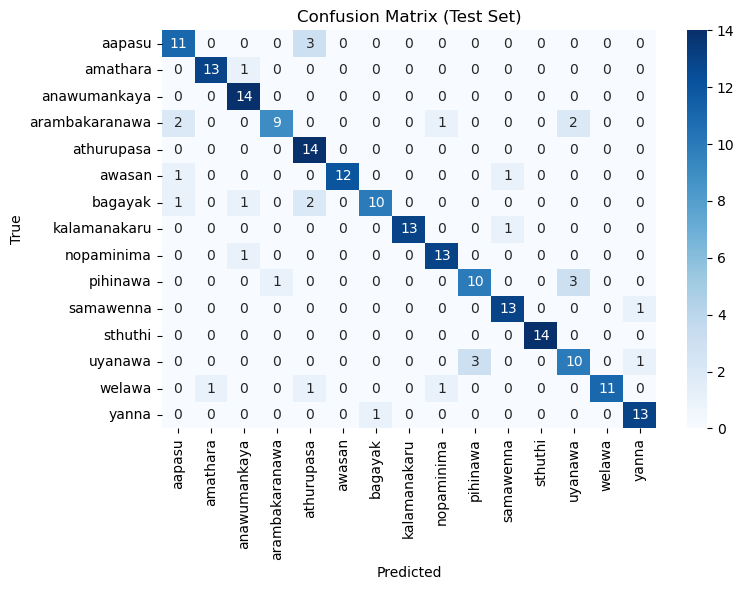

In [9]:
# Optional: Confusion matrix plot (run after evaluation)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [11]:
# Inference helper with consistent preprocessing
def predict_sentence(audio_path: str, model, mu: np.ndarray, sigma: np.ndarray, label_encoder: LabelEncoder):
    feat = extract_mfcc_features(audio_path)
    feat = standardize_apply(feat, mu, sigma)
    feat = feat.reshape(1, feat.shape[0], feat.shape[1])
    probs = model.predict(feat)[0]
    idx = int(np.argmax(probs))
    return label_encoder.inverse_transform([idx])[0], float(probs[idx])

# Example usage (commented):
# loaded_model = load_model(MODEL_OUT)
# le = joblib.load(LABELS_OUT)
# with open(NORM_STATS_OUT, "r", encoding="utf-8") as f:
#     stats = json.load(f)
# mu_loaded = np.array(stats["mu"], dtype=np.float32)
# sigma_loaded = np.array(stats["sigma"], dtype=np.float32)
# word, conf = predict_sentence("test1/Recording (12).wav", loaded_model, mu_loaded, sigma_loaded, le)
# print(f"Predicted: {word} (conf {conf:.2f})")